# $\mathbb{Z}_2^F \times \mathbb{Z}_2^T$ - Majorana - Open boundary conditions tripartite Schmidt decomposition

Created: 21-07-2026

Objectives:
* Apply methods from [this notebook](z2_f_x_z2_t_obc_tripartite_schmidt_decomposition.ipynb) to Majorana states.

# Imports

In [1]:
import numpy as np
import pandas as pd

In [2]:
import jax
jax.config.update('jax_platform_name', 'cpu')

import jax.numpy as jnp

In [3]:
import matplotlib.pyplot as plt

In [4]:
from tqdm import tqdm

In [5]:
from functools import reduce
from operator import mul

In [6]:
import quimb.tensor as qtn
import quimb as qu

In [7]:
from quspin.operators import hamiltonian
from quspin.operators import quantum_operator
from quspin.basis import spin_basis_1d, spinless_fermion_basis_1d, tensor_basis

In [8]:
from time import time

In [9]:
from humanize import naturalsize

In [10]:
import pickle

In [11]:
from functools import reduce
from operator import mul

from itertools import product

In [12]:
TOP_DATA_DIR = r"../../data/"
TRIV_COCYCLE_DIR = TOP_DATA_DIR + r"z2_f_x_z2_t_majorana_triv_to_nontriv_n1_10_site_ed_obc"
NONTRIV_COCYCLE_DIR = TOP_DATA_DIR + r"z2_f_x_z2_t_majorana_nontriv_n1_to_nontriv_cocyle_10_site_ed_obc"

# Import states

In [13]:
triv_groundstates = [
    np.load(rf'{TRIV_COCYCLE_DIR}/{i}.npz')['psi'][:, 0]
    for i in range(0, 101, 5)
]

In [14]:
triv_energies = [
    np.load(rf'{TRIV_COCYCLE_DIR}/{i}.npz')['energy']
    for i in range(0, 101, 5)
]

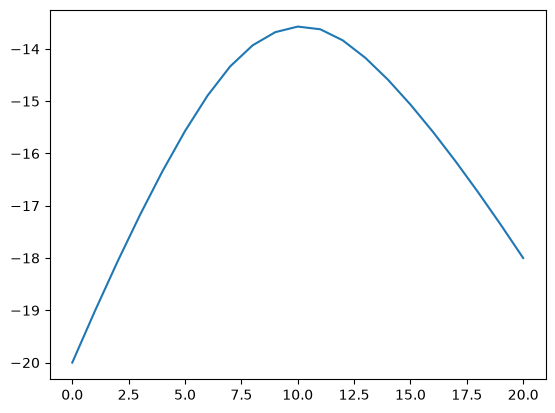

In [15]:
plt.plot(triv_energies)

In [16]:
nontriv_groundstates = [
    np.load(rf'{NONTRIV_COCYCLE_DIR}/{i}.npz')['psi'][:, 0]
    for i in range(0, 101, 5)
]

In [17]:
nontriv_groundstates[0].shape

(1048576,)

In [18]:
nontriv_energies = [
    np.load(rf'{NONTRIV_COCYCLE_DIR}/{i}.npz')['energy']
    for i in range(0, 101, 5)
]

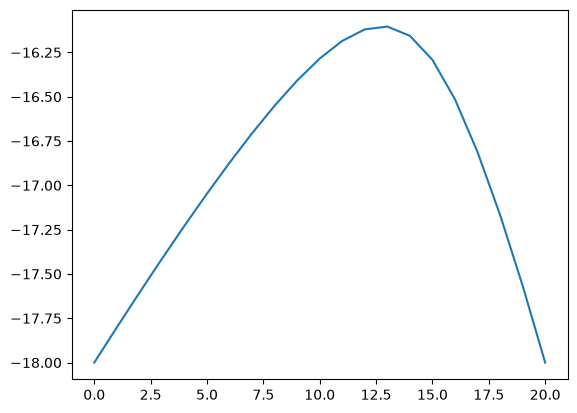

In [19]:
plt.plot(nontriv_energies)

# Definitions

In [20]:
L = 10

In [21]:
spin_basis = spin_basis_1d(L, pauli=-1)
fermion_basis = spinless_fermion_basis_1d(L)
basis = tensor_basis(spin_basis, fermion_basis)

In [22]:
parameters = np.linspace(0, 1, 201)

## Symmetries
Symmetry of the system is $XK$, where $K$ is complex conjugation.

In [23]:
np_I = np.array([
    [1,0],
    [0,1]
])

np_Z = np.array([
    [1,0],
    [0,-1]
])

In [24]:
# Fermion parity on fermion sites
qu_FP = qtn.Tensor(np_Z, inds=['k', 'b'])

In [25]:
def multikron(arrays):
    return reduce(np.kron, arrays)

In [26]:
def get_multisite_qu_X(num_sites):
    np_many_X = multikron([np_X]*num_sites)

    out = qtn.Tensor(
        np_many_X,
        inds=['k', 'b'],
        tags='mulit_site_X',
    )

    return out

In [27]:
def get_multisite_qu_FP(sites):
    # Assuming fermion sites are on odd sites
    arrays = [
        (np_Z if (i%2) else np_I)
        for i in sites
    ]

    np_multisite_FP = multikron(arrays)

    out = qtn.Tensor(
        np_multisite_FP,
        inds=['k', 'b'],
        tags='multisite_FP',
    )

    return out

## Defect operators

In [28]:
def get_defect_operators(edm, num_iters=20):
    # Assuming edm has indices [kl, kr, bl, br]
    scores = list()

    left_defect_op = qtn.tensor_builder.rand_tensor(
        (edm.ind_size('bl'), edm.ind_size('kl')),
        inds=['kl', 'bl'],
        dtype='complex64'
    )

    right_defect_op = qtn.tensor_builder.rand_tensor(
        (edm.ind_size('br'), edm.ind_size('kr')),
        inds=['kr', 'br'],
        dtype='complex64'
    )

    for _ in range(num_iters):
        right_edm = (
            (
                edm
                & left_defect_op.reindex({'kl': 'bl', 'bl':'kl'})
            )
            .contract()
        )
        data = right_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        right_defect_op = qtn.Tensor(sol, inds = ['kr', 'br'])
        
        left_edm = (
            (
                edm
                & right_defect_op.reindex({'kr': 'br', 'br':'kr'})
            )
            .contract()    
        )
        data = left_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        left_defect_op = qtn.Tensor(sol, inds = ['kl', 'bl'])

    return (left_defect_op, right_defect_op), scores

In [29]:
def get_edm_from_rho_tilde(rho_tilde, domains_dict):
    all_defect_sites = (
        domains_dict['left_defect_sites']
        + domains_dict['right_defect_sites']
    )
    central_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in all_defect_sites
    ]

    left_fuse_map = {
        'kl': [f'k{i}' for i in domains_dict['left_defect_sites']],
        'bl': [f'b{i}' for i in domains_dict['left_defect_sites']],
    }
    right_fuse_map = {
        'kr': [f'k{i}' for i in domains_dict['right_defect_sites']],
        'br': [f'b{i}' for i in domains_dict['right_defect_sites']]
    }
    fuse_map = left_fuse_map | right_fuse_map

    output_inds = sum(fuse_map.values(), [])

    edm = (
        rho_tilde.reindex({f'b{i}': f'k{i}' for i in central_sites})
        .contract(output_inds=output_inds)
        .fuse(fuse_map)
    )

    return edm

In [30]:
def get_defect_ops_and_indices_from_mps_decomposition(
    qt_rho, mps_decomp, domains_dict):

    all_defect_sites = (
        domains_dict['left_defect_sites']
        + domains_dict['right_defect_sites']
    )

    central_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in all_defect_sites
    ]

    left_fuse_map = {
        'kl': [f'k{i}' for i in domains_dict['left_defect_sites']],
        'bl': [f'b{i}' for i in domains_dict['left_defect_sites']],
    }
    right_fuse_map = {
        'kr': [f'k{i}' for i in domains_dict['right_defect_sites']],
        'br': [f'b{i}' for i in domains_dict['right_defect_sites']]
    }
    fuse_map = left_fuse_map | right_fuse_map

    rho_tilde = get_rho_tilde(mps_decomp, domains_dict)

    edm = get_edm_from_rho_tilde(rho_tilde, domains_dict)

    split_edm = qtn.tensor_core.tensor_split(
        edm,
        left_inds=['kl', 'bl'],
        absorb=None,
        bond_ind='vH'
    )

    left_right_singular_vals = split_edm.tensors[1].data

    (left_defect_operator, right_defect_operator), overlaps = (
        get_defect_operators(edm, num_iters=20)
    )

    not_left_defect_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in domains_dict['left_defect_sites']
    ]

    rho_defect_l = (
        qt_rho
        .reindex({f'k{i}': f'b{i}' for i in not_left_defect_sites})
        .contract()
        .fuse(left_fuse_map)
    )

    left_defect_qu_FP = get_multisite_qu_FP(
        domains_dict['left_defect_sites']
    )

    left_defect_op_n1_invariant = (
        rho_defect_l
        & left_defect_qu_FP.reindex({'b': 'kl', 'k': 'ki1'})
        & left_defect_operator.reindex({'bl': 'ki1', 'kl': 'ki2'}) 
        & left_defect_qu_FP.reindex({'b': 'ki2', 'k': 'ki3'})
        & left_defect_operator.conj().reindex({'kl': 'ki3', 'bl': 'bl'}) 
    )
    left_defect_op_n1_invariant=left_defect_op_n1_invariant.contract()

    left_defect_op_cocycle_invariant = (
        rho_defect_l
        & left_defect_operator.reindex({'bl': 'kl', 'kl': 'ki1'})
        & left_defect_operator.conj().reindex({'bl': 'ki1', 'kl': 'bl'})
    )
    left_defect_op_cocycle_invariant=left_defect_op_cocycle_invariant.contract()

    not_right_defect_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in domains_dict['right_defect_sites']
    ]

    rho_defect_r = (
        qt_rho
        .reindex({f'k{i}': f'b{i}' for i in not_right_defect_sites})
        .contract()
        .fuse(right_fuse_map)
    )

    right_defect_qu_FP = get_multisite_qu_FP(
        domains_dict['right_defect_sites']
    )

    right_defect_op_n1_invariant = (
        rho_defect_r
        & right_defect_qu_FP.reindex({'b': 'kr', 'k': 'ki1'})
        & right_defect_operator.reindex({'br': 'ki1', 'kr': 'ki2'}) 
        & right_defect_qu_FP.reindex({'b': 'ki2', 'k': 'ki3'})
        & right_defect_operator.conj().reindex({'kr': 'ki3', 'br': 'br'}) 
    )
    right_defect_op_n1_invariant=right_defect_op_n1_invariant.contract()

    right_defect_op_cocycle_invariant = (
        rho_defect_r
        & right_defect_operator.reindex({'br': 'kr', 'kr': 'ki1'})
        & right_defect_operator.conj().reindex({'br': 'ki1', 'kr': 'br'})
    )
    right_defect_op_cocycle_invariant=right_defect_op_cocycle_invariant.contract()

    overlap = (
        edm
        & left_defect_operator.reindex({'kl': 'bl', 'bl': 'kl'})
        & right_defect_operator.reindex({'kr': 'br', 'br': 'kr'})
    )

    overlap = np.abs(overlap.contract())

    out = (
        left_right_singular_vals,
        left_defect_operator,
        right_defect_operator,
        left_defect_op_n1_invariant,
        right_defect_op_n1_invariant,
        left_defect_op_cocycle_invariant,
        right_defect_op_cocycle_invariant,
        overlaps,
        overlap
    )

    return out

In [31]:
def get_left_right_defect_regions_schmidt_vals(qt_rho, domains_dict):
    unfuse_map = {
        'kl': ['kl1', 'kl2'],
        'kr': ['kr1', 'kr2'],
        'bl': ['bl1', 'bl2'],
        'br': ['br1', 'br2']
    }

    left_defect_op_dim = 2**(len(domains_dict['left_defect_sites']))
    right_defect_op_dim = 2**(len(domains_dict['right_defect_sites']))
    left_defect_complement_op_dim = 2**(
        len(domains_dict['left_symmetry_sites'])
        -len(domains_dict['left_defect_sites'])
    )
    right_defect_complement_op_dim = 2**(
        len(domains_dict['right_symmetry_sites'])
        -len(domains_dict['right_defect_sites'])
    )
    
    shape_map = {
        'kl': (left_defect_op_dim, left_defect_complement_op_dim),
        'kr': (right_defect_complement_op_dim, right_defect_op_dim),
        'bl': (left_defect_op_dim, left_defect_complement_op_dim),
        'br': (right_defect_complement_op_dim, right_defect_op_dim)
    }

    rho = (
        qt_rho
        .unfuse(unfuse_map=unfuse_map, shape_map=shape_map)
    )

    rho = rho.reindex({'kl2': 'bl2', 'kr1': 'br1'})
    rho = rho.contract()

    rho_left_right_split = qtn.tensor_core.tensor_split(
        rho,
        left_inds=['kl1', 'bl1'],
        method='svd',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vV'
    )

    rho_left_right_schmidt_vals = rho_left_right_split.tensors[1].data

    return rho_left_right_schmidt_vals

In [32]:
def get_rdm_from_quimb_psi(psi, symmetry_sites):
    rho = qtn.TensorNetwork(
        [psi, psi.conj().reindex({f'k{i}': f'b{i}' for i in symmetry_sites})],
        virtual=True
    )

    #rho.contract(inplace=True)

    return rho

In [33]:
def get_defect_ops_and_indices_from_rho_tilde(
    qt_rho, rho_tilde, domains_dict):

    all_defect_sites = (
        domains_dict['left_defect_sites']
        + domains_dict['right_defect_sites']
    )

    central_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in all_defect_sites
    ]

    left_fuse_map = {
        'kl': [f'k{i}' for i in domains_dict['left_defect_sites']],
        'bl': [f'b{i}' for i in domains_dict['left_defect_sites']],
    }
    right_fuse_map = {
        'kr': [f'k{i}' for i in domains_dict['right_defect_sites']],
        'br': [f'b{i}' for i in domains_dict['right_defect_sites']]
    }
    fuse_map = left_fuse_map | right_fuse_map

    edm = get_edm_from_rho_tilde(rho_tilde, domains_dict)

    split_edm = qtn.tensor_core.tensor_split(
        edm,
        left_inds=['kl', 'bl'],
        absorb=None,
        bond_ind='vH'
    )

    left_right_singular_vals = split_edm.tensors[1].data

    (left_defect_operator, right_defect_operator), overlaps = (
        get_defect_operators(edm, num_iters=20)
    )

    not_left_defect_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in domains_dict['left_defect_sites']
    ]

    rho_defect_l = (
        qt_rho
        .reindex({f'k{i}': f'b{i}' for i in not_left_defect_sites})
        .contract()
        .fuse(left_fuse_map)
    )

    left_defect_qu_FP = get_multisite_qu_FP(
        domains_dict['left_defect_sites']
    )

    left_defect_op_n1_invariant = (
        rho_defect_l
        & left_defect_qu_FP.reindex({'b': 'kl', 'k': 'ki1'})
        & left_defect_operator.reindex({'bl': 'ki1', 'kl': 'ki2'}) 
        & left_defect_qu_FP.reindex({'b': 'ki2', 'k': 'ki3'})
        & left_defect_operator.conj().reindex({'kl': 'ki3', 'bl': 'bl'}) 
    )
    left_defect_op_n1_invariant=left_defect_op_n1_invariant.contract()

    left_defect_op_cocycle_invariant = (
        rho_defect_l
        & left_defect_operator.reindex({'bl': 'kl', 'kl': 'ki1'})
        & left_defect_operator.conj().reindex({'bl': 'ki1', 'kl': 'bl'})
    )
    left_defect_op_cocycle_invariant=left_defect_op_cocycle_invariant.contract()

    not_right_defect_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in domains_dict['right_defect_sites']
    ]

    rho_defect_r = (
        qt_rho
        .reindex({f'k{i}': f'b{i}' for i in not_right_defect_sites})
        .contract()
        .fuse(right_fuse_map)
    )

    right_defect_qu_FP = get_multisite_qu_FP(
        domains_dict['right_defect_sites']
    )

    right_defect_op_n1_invariant = (
        rho_defect_r
        & right_defect_qu_FP.reindex({'b': 'kr', 'k': 'ki1'})
        & right_defect_operator.reindex({'br': 'ki1', 'kr': 'ki2'}) 
        & right_defect_qu_FP.reindex({'b': 'ki2', 'k': 'ki3'})
        & right_defect_operator.conj().reindex({'kr': 'ki3', 'br': 'br'}) 
    )
    right_defect_op_n1_invariant=right_defect_op_n1_invariant.contract()

    right_defect_op_cocycle_invariant = (
        rho_defect_r
        & right_defect_operator.reindex({'br': 'kr', 'kr': 'ki1'})
        & right_defect_operator.conj().reindex({'br': 'ki1', 'kr': 'br'})
    )
    right_defect_op_cocycle_invariant=right_defect_op_cocycle_invariant.contract()

    overlap = (
        edm
        & left_defect_operator.reindex({'kl': 'bl', 'bl': 'kl'})
        & right_defect_operator.reindex({'kr': 'br', 'br': 'kr'})
    )

    overlap = np.abs(overlap.contract())

    out = (
        left_right_singular_vals,
        left_defect_operator,
        right_defect_operator,
        left_defect_op_n1_invariant,
        right_defect_op_n1_invariant,
        left_defect_op_cocycle_invariant,
        right_defect_op_cocycle_invariant,
        overlaps,
        overlap
    )

    return out

# Test reconstruction of $\rho$

## Via expectation values

In [34]:
domains_dict = {
    'num_system_sites': 20,
    'symmetry_sites': list(range(8, 13)),
    'left_defect_sites': [8, 9],
    'right_defect_sites': [11, 12]
}

In [35]:
psi = triv_groundstates[0]

In [36]:
# Keys: output, input

spin_basis_ops = {
    (0,0): [('z', 0.5), ('I', 0.5)],
    (1,1): [('z', -0.5), ('I', 0.5)],
    (1,0): [('x', 0.5), ('y', 0.5j)],
    (0,1): [('x', 0.5), ('y', -0.5j)],
}

fermion_basis_ops = {
    (0,0): [('I', 1), ('n', -1)],
    (1,1): [('n', 1)],
    (1,0): [('+', 1)],
    (0,1): [('-', 1)],
}

In [37]:
basis_ops = {
    0: spin_basis_ops,
    1: fermion_basis_ops
}

In [38]:
num_symmetry_sites = len(domains_dict['symmetry_sites'])

data = np.zeros((2,)*(2*num_symmetry_sites), dtype=complex)

In [39]:
index_k = (0,)*num_symmetry_sites
index_b = (0,)*num_symmetry_sites

triples = zip(domains_dict['symmetry_sites'], index_k, index_b)

spin_op_pairs = list()
fermion_op_pairs = list()

for site_index, i_k, i_b in triples:
    #spin site
    if site_index%2 == 0:
        spin_op_pairs.append((site_index, spin_basis_ops[(i_k, i_b)]))
    #fermion site
    else:
        fermion_op_pairs.append((site_index, spin_basis_ops[(i_k, i_b)]))

In [40]:
spin_op_pairs

[(8, [('z', 0.5), ('I', 0.5)]),
 (10, [('z', 0.5), ('I', 0.5)]),
 (12, [('z', 0.5), ('I', 0.5)])]

In [41]:
fermion_op_pairs

[(9, [('z', 0.5), ('I', 0.5)]), (11, [('z', 0.5), ('I', 0.5)])]

In [42]:
def get_expectation_from_op_pair_lists(spin_op_pairs, fermion_op_pairs, psi,
                                       basis):
    #Shift specifies wether the first index is a spin (0) or a fermion (1)
    spin_indices, spin_ops = zip(*spin_op_pairs) if spin_op_pairs else ((), ())
    spin_op_combinations = list(product(*spin_ops))
    quspin_spin_indices = [i//2 for i in spin_indices]

    ferm_indices, ferm_ops = zip(*fermion_op_pairs) if fermion_op_pairs else ((), ())
    ferm_op_combinations = list(product(*ferm_ops))
    quspin_ferm_indices = [(i-1)//2 for i in ferm_indices] 

    terms = list()

    for spin_pairs_list in spin_op_combinations:
        spin_ops, spin_strengths = zip(*spin_pairs_list) if spin_pairs_list else ((), ())
        for ferm_pairs_list in ferm_op_combinations:
            ferm_ops, ferm_strengths = zip(*ferm_pairs_list) if ferm_pairs_list else ((), ())

            op_string = ''.join(spin_ops) + '|' + ''.join(ferm_ops)
            op_strength = reduce(mul, spin_strengths + ferm_strengths, 1)

            terms.append([op_string, [[op_strength, *quspin_spin_indices, *quspin_ferm_indices]]])

    op = hamiltonian(
        terms,
        [],
        basis=basis,
        check_herm=False,
        check_symm=False,
    )

    exp = op.expt_value(psi)

    return exp

In [43]:
get_expectation_from_op_pair_lists(
    spin_op_pairs,
    fermion_op_pairs,
    psi,
    basis
)

/var/folders/r3/xn8xq5c17932m2g1b4r3dss80000gn/T/ipykernel_61650/699245375.py:24: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  op = hamiltonian(


np.complex128(0.06250000000000011+0j)

In [44]:
def get_fermionic_rho(quspin_psi, domains_dict, verbose=False):
    L = domains_dict['num_system_sites']//2

    spin_basis = spin_basis_1d(L, pauli=-1)
    fermion_basis = spinless_fermion_basis_1d(L)
    basis = tensor_basis(spin_basis, fermion_basis)

    num_symmetry_sites = len(domains_dict['symmetry_sites'])
    
    data = np.zeros((2,)*(2*num_symmetry_sites), dtype=complex)

    all_k_indices = product(range(2), repeat=num_symmetry_sites)
    all_k_b_indices = list(product(all_k_indices, repeat=2))

    index_iter = tqdm(all_k_b_indices) if verbose else all_k_b_indices

    for index_k, index_b in index_iter:
        triples = zip(domains_dict['symmetry_sites'], index_k, index_b)

        spin_op_pairs = list()
        fermion_op_pairs = list()

        for site_index, i_k, i_b in triples:
            #spin site
            if site_index%2 == 0:
                spin_op_pairs.append((site_index, spin_basis_ops[(i_k, i_b)]))
            #fermion site
            else:
                fermion_op_pairs.append((site_index, fermion_basis_ops[(i_k, i_b)]))
    
        exp = get_expectation_from_op_pair_lists(
            spin_op_pairs,
            fermion_op_pairs,
            psi,
            basis
        )

        data[*index_k, *index_b] = exp.item()

    return data

In [193]:
rho = get_fermionic_rho(psi, domains_dict, verbose=True)

  0%|                                                                                       | 0/1024 [00:00<?, ?it/s]/var/folders/r3/xn8xq5c17932m2g1b4r3dss80000gn/T/ipykernel_61650/699245375.py:24: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  op = hamiltonian(
100%|████████████████████████████████████████████████████████████████████████████| 1024/1024 [01:25<00:00, 11.98it/s]


In [46]:
rho.shape

(2, 2, 2, 2, 2, 2, 2, 2, 2, 2)

## Via schmidt decomposition

In [47]:
all_defect_sites = (
    domains_dict['left_defect_sites']
    + domains_dict['right_defect_sites']
)
central_sites = [
    i for i in domains_dict['symmetry_sites']
    if i not in all_defect_sites
]

inds = (
    [f'k{2*i}' for i in range(domains_dict['num_system_sites']//2)]
    + [f'k{2*i+1}' for i in range(domains_dict['num_system_sites']//2)]
)

left_non_symmetry_sites = list(range(min(domains_dict['symmetry_sites'])))
right_non_symmetry_sites = list(range(
    max(domains_dict['symmetry_sites']),
    domains_dict['num_system_sites']
))

In [48]:
qt_psi = qtn.Tensor(
    psi[::-1].reshape((2,)*domains_dict['num_system_sites']),
    inds=inds
)

In [49]:
left_schmidt_decomp = qtn.tensor_core.tensor_split(
    qt_psi,
    left_inds=[f'k{i}' for i in left_non_symmetry_sites],
    absorb=None,
    bond_ind='vL'
)

right_schmidt_decomp = qtn.tensor_core.tensor_split(
    qt_psi,
    left_inds=[f'k{i}' for i in left_non_symmetry_sites+domains_dict['symmetry_sites']],
    absorb=None,
    bond_ind='vR'
)

psi_s = (
    qt_psi
    & left_schmidt_decomp.tensors[0].conj()
    & right_schmidt_decomp.tensors[2].conj()
).contract()

In [50]:
psi_s

Tensor(shape=(2, 2, 2, 2, 2, 1, 1), inds=('k8', 'k10', 'k12', 'k9', 'k11', 'vL', 'vR'), tags=oset([]))

In [51]:
domains_dict['symmetry_sites']

[8, 9, 10, 11, 12]

In [52]:
num_spin_symmetry_sites = len([
    i for i in domains_dict['symmetry_sites']
    if (i%2 == 0)
])

num_ferm_symmetry_sites = len([
    i for i in domains_dict['symmetry_sites']
    if (i%2 == 1)
])

sym_spin_basis = spin_basis_1d(num_spin_symmetry_sites, pauli=-1)
sym_fermion_basis = spinless_fermion_basis_1d(num_ferm_symmetry_sites)
sym_basis = tensor_basis(sym_spin_basis, sym_fermion_basis)

In [53]:
sub_psi_s = psi_s.isel({'vL': 0, 'vR': 0})

In [54]:
sub_psi_s

Tensor(shape=(2, 2, 2, 2, 2), inds=('k8', 'k10', 'k12', 'k9', 'k11'), tags=oset([]))

In [55]:
# Should really have a transpose in here.
quspin_psi_s = sub_psi_s.data.reshape(-1)[::-1]

In [129]:
# Lots of duplication of code here, oh well
def get_fermionic_rho_from_psi_s(quspin_psi_s, num_spin_sites, num_ferm_sites,
                                 verbose=False):
    # Assumes the incoming tensor is ordered as all spin sites, then all
    # fermion sites (each in order, respectively).

    spin_basis = spin_basis_1d(num_spin_sites, pauli=-1)
    ferm_basis = spinless_fermion_basis_1d(num_ferm_sites)
    basis = tensor_basis(spin_basis, ferm_basis)

    num_sites = num_spin_sites + num_ferm_sites
    data = np.zeros((2,)*(2*num_sites), dtype=complex)

    all_k_indices = product(range(2), repeat=num_sites)
    all_k_b_indices = list(product(all_k_indices, repeat=2))

    index_iter = tqdm(all_k_b_indices) if verbose else all_k_b_indices

    for index_k, index_b in index_iter:
        triples = zip(list(range(num_sites)), index_k, index_b)

        spin_op_pairs = list()
        fermion_op_pairs = list()

        for site_index, i_k, i_b in triples:
            #spin site
            if site_index%2 == 0:
                spin_op_pairs.append((site_index, spin_basis_ops[(i_k, i_b)]))
            #fermion site
            else:
                fermion_op_pairs.append((site_index, fermion_basis_ops[(i_k, i_b)]))
    
        exp = get_expectation_from_op_pair_lists(
            spin_op_pairs,
            fermion_op_pairs,
            quspin_psi_s,
            basis
        )

        data[*index_k, *index_b] = exp.item()

    return data

In [57]:
rho_s = get_fermionic_rho_from_psi_s(
    quspin_psi_s,
    3,
    2,
    verbose=True
)

  0%|                                                                                       | 0/1024 [00:00<?, ?it/s]/var/folders/r3/xn8xq5c17932m2g1b4r3dss80000gn/T/ipykernel_61650/699245375.py:24: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  op = hamiltonian(
100%|███████████████████████████████████████████████████████████████████████████| 1024/1024 [00:01<00:00, 614.78it/s]


In [58]:
rho_s.shape

(2, 2, 2, 2, 2, 2, 2, 2, 2, 2)

## Compare
### Traces

In [59]:
np.trace(rho.reshape((32, 32)))

np.complex128(1.0000000000000018+0j)

In [60]:
np.trace(rho_s.reshape((32, 32)))

np.complex128(1.0000000000000022+1.984165602510236e-17j)

### Norms

In [64]:
np.linalg.norm(rho.reshape((32, 32)))

np.float64(1.0000000000000018)

In [65]:
np.linalg.norm(rho_s.reshape((32, 32)))

np.float64(1.0000000000000022)

Promising...

### Take difference

In [66]:
np.linalg.norm(
    rho.reshape((32, 32)) - rho_s.reshape((32, 32))
)

np.float64(4.445322458709508e-16)

## Test with non-trivial $\psi$

In [116]:
psi = triv_groundstates[2]

In [117]:
domains_dict = {
    'num_system_sites': 20,
    'symmetry_sites': list(range(8, 13)),
    'left_defect_sites': [8, 9],
    'right_defect_sites': [11, 12]
}

In [118]:
rho = get_fermionic_rho(psi, domains_dict, verbose=True)

  0%|                                                                                       | 0/1024 [00:00<?, ?it/s]/var/folders/r3/xn8xq5c17932m2g1b4r3dss80000gn/T/ipykernel_61650/699245375.py:24: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  op = hamiltonian(
100%|████████████████████████████████████████████████████████████████████████████| 1024/1024 [01:28<00:00, 11.60it/s]


In [119]:
all_defect_sites = (
    domains_dict['left_defect_sites']
    + domains_dict['right_defect_sites']
)
central_sites = [
    i for i in domains_dict['symmetry_sites']
    if i not in all_defect_sites
]

inds = (
    [f'k{2*i}' for i in range(domains_dict['num_system_sites']//2)]
    + [f'k{2*i+1}' for i in range(domains_dict['num_system_sites']//2)]
)

left_non_symmetry_sites = list(range(min(domains_dict['symmetry_sites'])))
right_non_symmetry_sites = list(range(
    max(domains_dict['symmetry_sites']),
    domains_dict['num_system_sites']
))

In [120]:
qt_psi = qtn.Tensor(
    psi[::-1].reshape((2,)*domains_dict['num_system_sites']),
    inds=inds
)

In [121]:
left_schmidt_decomp = qtn.tensor_core.tensor_split(
    qt_psi,
    left_inds=[f'k{i}' for i in left_non_symmetry_sites],
    absorb=None,
    bond_ind='vL'
)

right_schmidt_decomp = qtn.tensor_core.tensor_split(
    qt_psi,
    left_inds=[f'k{i}' for i in left_non_symmetry_sites+domains_dict['symmetry_sites']],
    absorb=None,
    bond_ind='vR'
)

psi_s = (
    qt_psi
    & left_schmidt_decomp.tensors[0].conj()
    & right_schmidt_decomp.tensors[2].conj()
).contract()

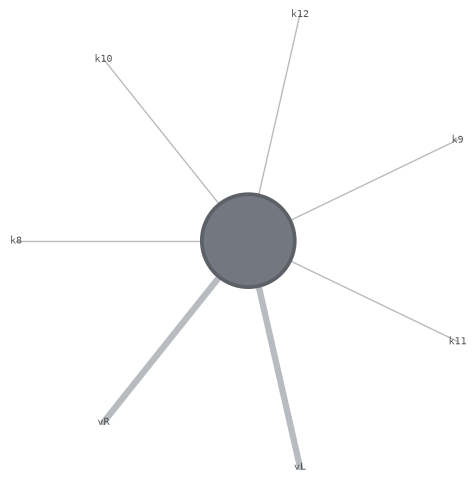

In [122]:
psi_s.draw()

In [123]:
num_spin_symmetry_sites = len([
    i for i in domains_dict['symmetry_sites']
    if (i%2 == 0)
])

num_ferm_symmetry_sites = len([
    i for i in domains_dict['symmetry_sites']
    if (i%2 == 1)
])

sym_spin_basis = spin_basis_1d(num_spin_symmetry_sites, pauli=-1)
sym_fermion_basis = spinless_fermion_basis_1d(num_ferm_symmetry_sites)
sym_basis = tensor_basis(sym_spin_basis, sym_fermion_basis)

In [124]:
psi_s.ind_size('vR')

23

In [125]:
psi_s.ind_size('vL')

23

In [126]:
domains_dict['symmetry_sites']

[8, 9, 10, 11, 12]

In [131]:
fixed_virtual_indices_rho_s = list()

even_sym_inds = [
    i for i in domains_dict['symmetry_sites']
    if i%2 == 0
]

odd_sym_inds = [
    i for i in domains_dict['symmetry_sites']
    if i%2 == 1
]

even_odd_sym_inds = even_sym_inds + odd_sym_inds

sym_inds = [f'k{i}' for i in even_odd_sym_inds]

for iL in tqdm(range(psi_s.ind_size('vL'))):
    fixed_virtual_indices_rho_s.append(list())
    for iR in range(psi_s.ind_size('vR')):
        sub_psi_s = psi_s.isel({'vL': iL, 'vR': iR})
        
        quspin_psi_s = (
            sub_psi_s
            .transpose(*sym_inds)
            .data
            .reshape(-1)[::-1]
        )

        rho_s = get_fermionic_rho_from_psi_s(
            quspin_psi_s,
            len(even_sym_inds),
            len(odd_sym_inds)
        )
        # I forgot to save rho_s, ugh.

  0%|                                                                                         | 0/23 [00:00<?, ?it/s]/var/folders/r3/xn8xq5c17932m2g1b4r3dss80000gn/T/ipykernel_61650/699245375.py:24: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  op = hamiltonian(
100%|████████████████████████████████████████████████████████████████████████████████| 23/23 [14:31<00:00, 37.88s/it]


## Speed up functions

In [183]:
spin_change_of_basis_matrix = 0.5*np.array([
    [1, 1, 0, 0],
    [1, -1, 0, 0],
    [0, 0, 1, 1j],
    [0, 0, 1, -1j]
])

ferm_change_of_basis_matrix = np.array([
    [1, -1, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 1, 0],
    [0, 0, 0, 1]
])

In [134]:
simple_spin_ops = 'Izxy'
simple_ferm_ops = 'In+-'

In [189]:
def get_fermionic_rho_fast(quspin_psi, domains_dict, verbose=False):
    # Output rho has indices k0, b0, k1, b1, etc...
    L = domains_dict['num_system_sites']//2

    spin_basis = spin_basis_1d(L, pauli=-1)
    fermion_basis = spinless_fermion_basis_1d(L)
    basis = tensor_basis(spin_basis, fermion_basis)

    sym_sites = domains_dict['symmetry_sites']
    num_symmetry_sites = len(sym_sites)

    spin_symmetry_sites = [
        i//2 for i in domains_dict['symmetry_sites']
        if (i%2 == 0)
    ]
    
    ferm_symmetry_sites = [
        (i-1)//2 for i in domains_dict['symmetry_sites']
        if (i%2 == 1)
    ]

    num_spin_sym_sites = len(spin_symmetry_sites)
    num_ferm_sym_sites = len(ferm_symmetry_sites)
    num_symmetry_sites = len(sym_sites)

    spin_ops_iter = product(simple_spin_ops, repeat=num_spin_sym_sites)
    spin_indices_iter = product(
        range(len(simple_spin_ops)),
        repeat=num_spin_sym_sites
    )
    spin_iter = zip(spin_indices_iter, spin_ops_iter)

    ferm_ops_iter = product(simple_ferm_ops, repeat=num_ferm_sym_sites)
    ferm_indices_iter = product(
        range(len(simple_ferm_ops)),
        repeat=num_ferm_sym_sites
    )
    ferm_iter = zip(ferm_indices_iter, ferm_ops_iter)

    index = spin_symmetry_sites + ferm_symmetry_sites

    data = np.zeros((4,)*(num_symmetry_sites), dtype=complex)

    if verbose:
        spin_ferm_iter = tqdm(list(product(spin_iter, ferm_iter)))
    else:
        spin_ferm_iter = list(product(spin_iter, ferm_iter))

    for spin_pair, ferm_pair in spin_ferm_iter:
        spin_index, spin_op = spin_pair
        ferm_index, ferm_op = ferm_pair

        spin_op_string = ''.join(spin_op)
        ferm_op_string = ''.join(ferm_op)

        terms = [[f'{spin_op_string}|{ferm_op_string}', [[1, *index]]]]

        op = hamiltonian(
            terms,
            [],
            basis=basis,
            check_herm=False,
            check_symm=False,
        )

        exp = op.expt_value(quspin_psi)

        data[*spin_index, *ferm_index] = exp

    for i in range(num_spin_sym_sites):
        data = np.tensordot(
            spin_change_of_basis_matrix,
            data,
            axes=[[1,], [i,]]
        )

    for i in range(num_spin_sym_sites, num_symmetry_sites):
        data = np.tensordot(
            ferm_change_of_basis_matrix,
            data,
            axes=[[1,], [i,]]
        )

    data = data.reshape((2,)*(2*num_symmetry_sites))

    return data

In [184]:
domains_dict = {
    'num_system_sites': 20,
    'symmetry_sites': list(range(8, 13)),
    'left_defect_sites': [8, 9],
    'right_defect_sites': [11, 12]
}

In [185]:
psi = triv_groundstates[0]

In [186]:
L = domains_dict['num_system_sites']//2

spin_basis = spin_basis_1d(L, pauli=-1)
fermion_basis = spinless_fermion_basis_1d(L)
basis = tensor_basis(spin_basis, fermion_basis)

sym_sites = domains_dict['symmetry_sites']
num_symmetry_sites = len(sym_sites)

spin_symmetry_sites = [
    i//2 for i in domains_dict['symmetry_sites']
    if (i%2 == 0)
]

ferm_symmetry_sites = [
    (i-1)//2 for i in domains_dict['symmetry_sites']
    if (i%2 == 1)
]

num_spin_sym_sites = len(spin_symmetry_sites)
num_ferm_sym_sites = len(ferm_symmetry_sites)
num_symmetry_sites = len(sym_sites)

In [187]:
print(
    num_spin_sym_sites,
    num_ferm_symmetry_sites
)

3 2


In [190]:
rho_fast = get_fermionic_rho_fast(psi, domains_dict, verbose=True)

  0%|                                                                                       | 0/1024 [00:00<?, ?it/s]/var/folders/r3/xn8xq5c17932m2g1b4r3dss80000gn/T/ipykernel_61650/2299234239.py:58: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  op = hamiltonian(
100%|███████████████████████████████████████████████████████████████████████████| 1024/1024 [00:06<00:00, 147.65it/s]


In [191]:
rho_fast.shape

(2, 2, 2, 2, 2, 2, 2, 2, 2, 2)

In [194]:
rho.shape

(2, 2, 2, 2, 2, 2, 2, 2, 2, 2)

In [195]:
num_symmetry_sites = len(domains_dict['symmetry_sites'])

In [196]:
rho_fast_transposed = rho_fast.transpose(*(
    [2*i for i in range(num_symmetry_sites)]
    +[2*i+1 for i in range(num_symmetry_sites)]
))

In [197]:
np.trace(rho_fast_transposed.reshape(32, 32,))

np.complex128(1.0000000000000024-1.2080939767640195e-14j)

Still have trace 1, nice.

In [198]:
np.linalg.norm(rho_fast_transposed - rho)

np.float64(2.052812921912431e-14)

# Sweep

In [33]:
domains_dict = {
    'num_system_sites': 20,
    'symmetry_sites': list(range(6, 15)),
    'left_defect_sites': [6, 7],
    'right_defect_sites': [13, 14]
}

all_defect_sites = (
    domains_dict['left_defect_sites']
    + domains_dict['right_defect_sites']
)
central_sites = [
    i for i in domains_dict['symmetry_sites']
    if i not in all_defect_sites
]

inds = (
    [f'k{2*i}' for i in range(domains_dict['num_system_sites']//2)]
    + [f'k{2*i+1}' for i in range(domains_dict['num_system_sites']//2)]
)

left_non_symmetry_sites = list(range(min(domains_dict['symmetry_sites'])))
right_non_symmetry_sites = list(range(
    max(domains_dict['symmetry_sites']),
    domains_dict['num_system_sites']
))

In [54]:
psi = triv_groundstates[0]

In [55]:
psi_s = (
    qt_psi
    & left_schmidt_decomp.tensors[0].conj()
    & right_schmidt_decomp.tensors[2].conj()
).contract()

In [56]:
psi_s

Tensor(shape=(2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 4), inds=('k6', 'k8', 'k10', 'k12', 'k14', 'k7', 'k9', 'k11', 'k13', 'vL', 'vR'), tags=oset([]))

In [68]:
TL, s, TR = qtn.tensor_core.tensor_split(
    qt_psi,
    left_inds=[f'k{i}' for i in left_non_symmetry_sites],
    absorb=None,
    bond_ind='vL'
)

psi_rec = TL & s & TR

In [63]:
TL

Tensor(shape=(2, 2, 2, 2, 2, 2, 4), inds=('k0', 'k1', 'k2', 'k3', 'k4', 'k5', 'vL'), tags=oset([]), left_inds=('k0', 'k1', 'k2', 'k3', 'k4', 'k5'))

In [64]:
s

Tensor(shape=(4,), inds=('vL',), tags=oset([]))

In [67]:
s.data

array([0.57778234, 0.57778234, 0.40763656, 0.40763656])

In [65]:
TR

Tensor(shape=(4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2), inds=('vL', 'k6', 'k8', 'k10', 'k12', 'k14', 'k16', 'k18', 'k7', 'k9', 'k11', 'k13', 'k15', 'k17', 'k19'), tags=oset([]), left_inds=('k6', 'k8', 'k10', 'k12', 'k14', 'k16', 'k18', 'k7', 'k9', 'k11', 'k13', 'k15', 'k17', 'k19'))

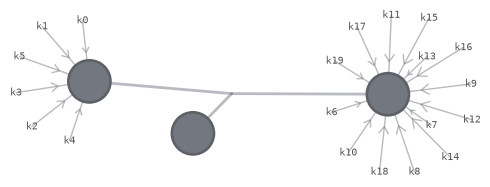

In [69]:
psi_rec.draw()

In [73]:
(psi_rec & psi_rec.conj()).contract(output_inds=[])

np.complex128(0.9999999999999796-3.503246160812043e-46j)

In [74]:
(qt_psi & qt_psi.conj()).contract()

np.complex128(0.9999999999928378+1.7821920849701162e-20j)

In [75]:
(qt_psi & psi_rec.conj()).contract(output_inds=[])

np.complex128(0.9999999999999867-1.398035040890349e-14j)

Ok, so the Scmidt decomposition is working as intended, I think.

In [34]:
triv_results = list()

for psi in tqdm(triv_groundstates):
    qt_psi = qtn.Tensor(
        psi[::-1].reshape((2,)*domains_dict['num_system_sites']),
        inds=inds
    )

    left_schmidt_decomp = qtn.tensor_core.tensor_split(
        qt_psi,
        left_inds=[f'k{i}' for i in left_non_symmetry_sites],
        absorb=None,
        bond_ind='vL'
    )

    right_schmidt_decomp = qtn.tensor_core.tensor_split(
        qt_psi,
        left_inds=[f'k{i}' for i in left_non_symmetry_sites+domains_dict['symmetry_sites']],
        absorb=None,
        bond_ind='vR'
    )

    psi_s = (
        qt_psi
        & left_schmidt_decomp.tensors[0].conj()
        & right_schmidt_decomp.tensors[2].conj()
    ).contract()

    rho_trace_test = (psi_s & psi_s.conj()).contract()

    rho_tilde = (
        psi_s
        & psi_s.reindex({f'k{i}': f'b{i}' for i in domains_dict['symmetry_sites']})
    )

    rho_tilde.contract(
        output_inds=rho_tilde.outer_inds(),
        inplace=True
    )

    edm = get_edm_from_rho_tilde(rho_tilde, domains_dict)

    qt_rho = (
        qt_psi
        & qt_psi.conj().reindex({f'k{i}': f'b{i}' for i in domains_dict['symmetry_sites']})
    )

    defect_out = get_defect_ops_and_indices_from_rho_tilde(
        qt_rho,
        rho_tilde,
        domains_dict
    )

    triv_results.append([rho_trace_test, *defect_out])

100%|████████████████████████████████████████████████████████████████████████████████| 21/21 [00:06<00:00,  3.29it/s]


In [35]:
nontriv_results = list()

for psi in tqdm(nontriv_groundstates):
    qt_psi = qtn.Tensor(
        psi[::-1].reshape((2,)*domains_dict['num_system_sites']),
        inds=inds
    )

    left_schmidt_decomp = qtn.tensor_core.tensor_split(
        qt_psi,
        left_inds=[f'k{i}' for i in left_non_symmetry_sites],
        absorb=None,
        bond_ind='vL'
    )

    right_schmidt_decomp = qtn.tensor_core.tensor_split(
        qt_psi,
        left_inds=[f'k{i}' for i in left_non_symmetry_sites+domains_dict['symmetry_sites']],
        absorb=None,
        bond_ind='vR'
    )

    psi_s = (
        qt_psi
        & left_schmidt_decomp.tensors[0].conj()
        & right_schmidt_decomp.tensors[2].conj()
    ).contract()

    rho_trace_test = (psi_s & psi_s.conj()).contract()

    rho_tilde = (
        psi_s
        & psi_s.reindex({f'k{i}': f'b{i}' for i in domains_dict['symmetry_sites']})
    )

    rho_tilde.contract(
        output_inds=rho_tilde.outer_inds(),
        inplace=True
    )

    edm = get_edm_from_rho_tilde(rho_tilde, domains_dict)

    qt_rho = (
        qt_psi
        & qt_psi.conj().reindex({f'k{i}': f'b{i}' for i in domains_dict['symmetry_sites']})
    )

    defect_out = get_defect_ops_and_indices_from_rho_tilde(
        qt_rho,
        rho_tilde,
        domains_dict
    )

    nontriv_results.append([rho_trace_test, *defect_out])

100%|████████████████████████████████████████████████████████████████████████████████| 21/21 [00:05<00:00,  3.56it/s]


## Analyze results
### Trivial

In [36]:
[
    l[0] for l in triv_results
]

[np.complex128(1.000000000000002+0j),
 np.complex128(0.9999999999999785+0j),
 np.complex128(1.0000000000000093+0j),
 np.complex128(1.0000000000000215+0j),
 np.complex128(1.0000000000000033+0j),
 np.complex128(0.9999999999999898+0j),
 np.complex128(1.0000000000000056+0j),
 np.complex128(1.0000000000000073+0j),
 np.complex128(1.0000000000000004+0j),
 np.complex128(0.9999999999999933+0j),
 np.complex128(0.9999999999999949+0j),
 np.complex128(0.9999999999999897+0j),
 np.complex128(0.9999999999999925+0j),
 np.complex128(0.9999999999999654+0j),
 np.complex128(0.9999999999999762+0j),
 np.complex128(0.9999999999999896+0j),
 np.complex128(0.9999999999999837+0j),
 np.complex128(0.9999999999999796+0j),
 np.complex128(0.9999999999999815+0j),
 np.complex128(0.9999999999999881+0j),
 np.complex128(0.9999999999999839+0j)]

In [37]:
[
    l[1] for l in triv_results
]

[array([1.]),
 array([9.96532569e-01, 1.81920174e-04, 3.63569516e-05, 1.04577403e-06,
        1.49411255e-07, 6.63873173e-09, 1.90806223e-10]),
 array([9.84459866e-01, 1.69820041e-03, 3.39918534e-04, 2.05491931e-05,
        2.93454864e-06, 5.86218602e-07, 3.54584102e-08, 7.08721023e-09,
        5.06749466e-09, 1.01278631e-09]),
 array([9.60476994e-01, 6.74796472e-03, 1.32955540e-03, 1.28058858e-04,
        1.82146773e-05, 9.38809750e-06, 8.85250301e-07, 1.79856219e-07,
        1.27062284e-07, 2.57999078e-08, 2.43354455e-09, 1.24604165e-09,
        1.77211305e-10]),
 array([9.20976394e-01, 1.99063822e-02, 3.37782252e-03, 4.87206714e-04,
        7.69890453e-05, 7.18369461e-05, 9.45153811e-06, 2.23035471e-06,
        1.30692443e-06, 3.09360275e-07, 3.89777843e-08, 3.79134837e-08,
        5.74878787e-09, 7.60877670e-10, 1.04078368e-10]),
 array([8.52870268e-01, 4.39870650e-02, 7.92739509e-03, 1.41448718e-03,
        4.22333796e-04, 2.15636097e-04, 7.05676551e-05, 1.57894901e-05,
        9.

In [38]:
n1_invariants = np.array([
    [l[4], l[5]] for l in triv_results
])

In [39]:
np.round(n1_invariants, 3)

array([[ 1.   -0.j   ,  1.   -0.j   ],
       [ 1.   +0.j   ,  1.   +0.j   ],
       [ 1.   +0.j   ,  1.   -0.j   ],
       [ 1.   +0.j   ,  1.   +0.j   ],
       [ 1.   +0.j   ,  1.   -0.j   ],
       [ 1.   +0.j   ,  1.   +0.j   ],
       [ 1.   +0.j   ,  1.   +0.j   ],
       [ 1.   +0.j   ,  1.   +0.j   ],
       [ 1.   +0.j   ,  1.   +0.j   ],
       [ 1.   +0.j   ,  1.   +0.j   ],
       [ 1.   +0.j   ,  1.   +0.j   ],
       [-1.   +0.j   , -1.   -0.j   ],
       [-1.   +0.j   , -1.   +0.j   ],
       [-0.904-0.j   , -0.893-0.j   ],
       [ 0.328+0.j   ,  0.349+0.j   ],
       [ 0.075-0.j   ,  0.084-0.j   ],
       [-0.921-0.j   , -0.92 -0.j   ],
       [-0.771+0.j   , -0.711+0.j   ],
       [ 0.988+0.j   ,  0.667-0.001j],
       [ 0.977-0.j   ,  0.304+0.j   ],
       [-0.998+0.j   , -0.966+0.j   ]])

Something funny happening at the end, likely Hamiltonian specific.

In [40]:
cocycle_invariants = np.array([
    [l[6], l[7]] for l in triv_results
])

In [41]:
np.round(cocycle_invariants, 3)

array([[ 1.   +0.j,  1.   +0.j],
       [ 1.   +0.j,  1.   -0.j],
       [ 1.   +0.j,  1.   +0.j],
       [ 1.   +0.j,  1.   +0.j],
       [ 1.   +0.j,  1.   +0.j],
       [ 1.   -0.j,  1.   +0.j],
       [ 1.   +0.j,  1.   +0.j],
       [ 1.   +0.j,  1.   -0.j],
       [ 1.   -0.j,  1.   +0.j],
       [ 1.   +0.j,  1.   +0.j],
       [ 1.   +0.j,  1.   -0.j],
       [-1.   -0.j, -1.   -0.j],
       [-1.   +0.j, -1.   +0.j],
       [-1.   +0.j, -1.   +0.j],
       [-1.   +0.j, -1.   +0.j],
       [-1.   -0.j, -1.   -0.j],
       [-0.992+0.j, -0.991+0.j],
       [-1.   +0.j, -1.   +0.j],
       [-1.   +0.j, -1.   -0.j],
       [-1.   +0.j, -1.   +0.j],
       [-1.   +0.j, -1.   +0.j]])

But the cocycle invariant is still wrong! Interesting.

In [42]:
overlaps = [l[-1] for l in triv_results]

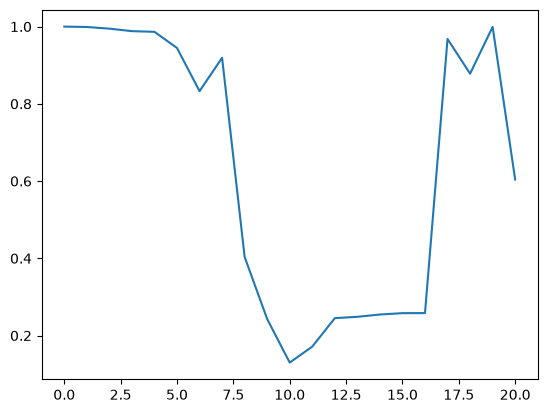

In [43]:
plt.plot(overlaps)

Much noisier overlaps than I was expecting...! Dependent on the choice of boundary/edge states?

### Non-trivial

In [44]:
[
    l[0] for l in nontriv_results
]

[np.complex128(0.9999999999999937+0j),
 np.complex128(0.9999999999999953+0j),
 np.complex128(0.9999999999999971+0j),
 np.complex128(0.9999999999999868+0j),
 np.complex128(1.0000000000000147+0j),
 np.complex128(1.0000000000000018+0j),
 np.complex128(0.9999999999999943+0j),
 np.complex128(0.9999999999999987+0j),
 np.complex128(1.0000000000000009+0j),
 np.complex128(1.0000000000000013+0j),
 np.complex128(1.0000000000000098+0j),
 np.complex128(0.9999999999999869+0j),
 np.complex128(1.0000000000000013+0j),
 np.complex128(1.0000000000000113+0j),
 np.complex128(0.9999999999999916+0j),
 np.complex128(0.999999999999994+0j),
 np.complex128(0.9999999999999971+0j),
 np.complex128(0.9999999999999911+0j),
 np.complex128(0.9999999999999851+0j),
 np.complex128(1.0000000000000053+0j),
 np.complex128(1.0000000000000129+0j)]

In [45]:
[
    l[1] for l in nontriv_results
]

[array([0.24359966, 0.00304775]),
 array([2.13900591e-01, 2.81473271e-03, 1.25979473e-05, 5.80584476e-07]),
 array([0.18078434, 0.03289798, 0.00502427, 0.0009177 ]),
 array([2.41786264e-01, 1.06826426e-02, 3.98862894e-03, 1.77219523e-04]),
 array([0.18240768, 0.01852947, 0.01142982, 0.00118933]),
 array([0.24197708, 0.02025605, 0.00532907, 0.00055716]),
 array([0.24166706, 0.02609406, 0.00279845, 0.00060796]),
 array([2.34064172e-01, 3.18862525e-02, 3.54671179e-03, 1.14519543e-04]),
 array([0.20543427, 0.03492536, 0.01123788, 0.0028928 ]),
 array([0.21420259, 0.04487986, 0.00876819, 0.00384088]),
 array([0.20494386, 0.05347214, 0.01125796, 0.00595066]),
 array([0.19840261, 0.06372587, 0.0118886 , 0.01182115]),
 array([0.15841186, 0.06413659, 0.02573602, 0.02546635]),
 array([0.11039833, 0.05455167, 0.04164027, 0.02266338]),
 array([0.08612938, 0.06432937, 0.03930543, 0.03673971]),
 array([0.11819776, 0.03974591, 0.01414511, 0.0041491 ]),
 array([0.19154469, 0.04848398, 0.01231626, 0.00

In [46]:
n1_invariants = np.array([
    [l[4], l[5]] for l in nontriv_results
])

In [47]:
np.round(n1_invariants, 3)

array([[ 0.895+0.j,  0.986-0.j],
       [-1.   +0.j, -1.   +0.j],
       [-1.   +0.j, -1.   +0.j],
       [-1.   -0.j, -1.   +0.j],
       [-1.   +0.j, -1.   +0.j],
       [-1.   +0.j, -1.   +0.j],
       [-1.   +0.j, -1.   +0.j],
       [-1.   +0.j, -1.   +0.j],
       [-1.   +0.j, -1.   +0.j],
       [-1.   +0.j, -1.   +0.j],
       [-1.   +0.j, -1.   +0.j],
       [-1.   -0.j, -1.   +0.j],
       [-1.   +0.j, -1.   +0.j],
       [-1.   +0.j, -1.   +0.j],
       [-1.   -0.j, -1.   +0.j],
       [-1.   +0.j, -1.   -0.j],
       [-1.   +0.j, -1.   +0.j],
       [-1.   +0.j, -1.   +0.j],
       [-1.   +0.j, -1.   -0.j],
       [-1.   +0.j, -1.   -0.j],
       [-1.   +0.j, -1.   +0.j]])

Something funny happening at the fixed points...?

In [48]:
cocycle_invariants = np.array([
    [l[6], l[7]] for l in nontriv_results
])

In [49]:
np.round(cocycle_invariants, 3)

array([[-1.+0.j, -1.+0.j],
       [-1.+0.j, -1.+0.j],
       [-1.+0.j, -1.+0.j],
       [-1.+0.j, -1.+0.j],
       [-1.+0.j, -1.+0.j],
       [-1.-0.j, -1.-0.j],
       [-1.+0.j, -1.+0.j],
       [-1.+0.j, -1.+0.j],
       [-1.+0.j, -1.-0.j],
       [-1.-0.j, -1.-0.j],
       [-1.+0.j, -1.+0.j],
       [-1.+0.j, -1.+0.j],
       [-1.-0.j, -1.+0.j],
       [-1.-0.j, -1.+0.j],
       [ 1.-0.j,  1.-0.j],
       [ 1.+0.j,  1.+0.j],
       [ 1.+0.j,  1.+0.j],
       [ 1.+0.j,  1.+0.j],
       [ 1.-0.j,  1.-0.j],
       [ 1.+0.j,  1.+0.j],
       [ 1.+0.j,  1.+0.j]])

But the cocycle invariant is the same as we had before! Interesting. So our invariant is definitely wrong.

In [50]:
overlaps = [l[-1] for l in triv_results]

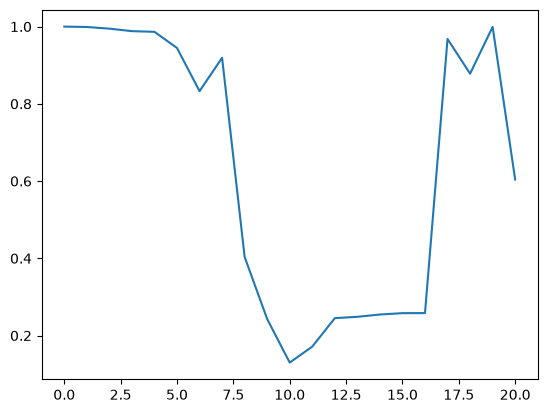

In [51]:
plt.plot(overlaps)

Still noisy...

### Defect operators

In [52]:
X =triv_results[0][2].data
phase = X[0,0]/np.abs(X[0,0])

np.round(X/phase, 3)

array([[ 0.087-0.j   , -0.183-0.738j, -0.   -0.j   , -0.257-0.589j],
       [ 0.105-0.003j,  0.056+0.646j, -0.   -0.j   , -0.187-0.73j ],
       [-0.   +0.j   ,  0.   +0.j   , -0.637+0.771j,  0.   +0.j   ],
       [-0.813-0.567j, -0.012-0.004j,  0.   +0.j   ,  0.041-0.129j]])

In [53]:
X =triv_results[0][3].data
phase = X[0,0]/np.abs(X[0,0])

np.round(X/phase, 3)

array([[ 0.425-0.j   , -0.   +0.j   , -0.14 -0.211j, -0.279-0.823j],
       [ 0.   -0.j   ,  0.575-0.818j,  0.   +0.j   , -0.   -0.j   ],
       [-0.088+0.004j,  0.   -0.j   , -0.705-0.662j,  0.133+0.199j],
       [ 0.573+0.695j,  0.   -0.j   , -0.024+0.021j, -0.224+0.371j]])

In [68]:
X =triv_results[-1][2].data
phase = X[0,1]/np.abs(X[0,1])

np.round(X/phase, 3)

array([[ 0.   +0.j,  0.261+0.j, -0.525+0.j, -0.81 -0.j],
       [-0.261+0.j,  0.   +0.j,  0.81 -0.j, -0.525+0.j],
       [ 0.525+0.j, -0.81 +0.j, -0.   -0.j, -0.261+0.j],
       [ 0.81 +0.j,  0.525-0.j,  0.261-0.j, -0.   +0.j]])

In [69]:
X =triv_results[-1][3].data
phase = X[0,1]/np.abs(X[0,1])

np.round(X/phase, 3)

array([[-0.   -0.j,  0.893+0.j,  0.246-0.j,  0.377+0.j],
       [-0.893+0.j,  0.   -0.j,  0.377+0.j, -0.246-0.j],
       [-0.246+0.j, -0.377+0.j,  0.   -0.j,  0.893+0.j],
       [-0.377-0.j,  0.246+0.j, -0.893-0.j,  0.   +0.j]])

In [71]:
X =nontriv_results[0][2].data
phase = X[0,1]/np.abs(X[0,1])

np.round(X/phase, 3)

array([[-0.   +0.j,  0.045-0.j,  0.465-0.j, -0.884+0.j],
       [-0.045+0.j, -0.   -0.j,  0.884-0.j,  0.465-0.j],
       [-0.465+0.j, -0.884+0.j,  0.   -0.j, -0.045+0.j],
       [ 0.884-0.j, -0.465+0.j,  0.045-0.j,  0.   -0.j]])

In [75]:
X =nontriv_results[0][3].data
phase = X[0,0]/np.abs(X[0,0])

np.round(X/phase, 3)

array([[ 0.   +0.j   , -0.201+0.28j ,  0.484-0.674j,  0.256-0.356j],
       [ 0.201-0.28j , -0.   -0.j   ,  0.256-0.356j, -0.484+0.674j],
       [-0.484+0.674j, -0.256+0.356j, -0.   +0.j   , -0.201+0.28j ],
       [-0.256+0.356j,  0.484-0.674j,  0.201-0.28j , -0.   +0.j   ]])

In [77]:
X =nontriv_results[-1][2].data
phase = X[0,0]/np.abs(X[0,0])

np.round(X/phase, 3)

array([[ 0.619-0.j   , -0.   -0.779j, -0.   +0.j   ,  0.   +0.101j],
       [ 0.   -0.779j,  0.619-0.j   , -0.   +0.101j,  0.   +0.j   ],
       [ 0.   +0.j   ,  0.   +0.101j,  0.619-0.j   ,  0.   +0.779j],
       [ 0.   +0.101j, -0.   +0.j   ,  0.   +0.779j,  0.619-0.j   ]])

In [79]:
X =nontriv_results[-1][3].data
phase = X[0,0]/np.abs(X[0,0])

np.round(X/phase, 3)

array([[ 0.869+0.j   ,  0.   +0.494j, -0.   +0.j   , -0.   +0.025j],
       [-0.   +0.494j,  0.869+0.j   ,  0.   -0.025j,  0.   -0.j   ],
       [-0.   +0.j   ,  0.   -0.025j,  0.869-0.j   ,  0.   +0.494j],
       [ 0.   +0.025j, -0.   -0.j   , -0.   +0.494j,  0.869-0.j   ]])

# Conclusions
1. Are there problems in our groundstate energies, especially in for the nontrivial cocycles? Problem in Hamiltonian definition?
2. The calculated $n_1$ values are cleaner here, indicating there is something wrong with the tensor network factorization.
3. The calculated values of $\nu_2$ look good, but seem multiplied by $(-1)^{n_1}$. Why?